In [1]:
import pandas as pd
import numpy as np

import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


c:\Users\usuario\Desktop\Python Projects\customer-churn-intelligence\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load data

df = pd.read_csv(
    "../data/processed/churn_model_dataset.csv"
)

df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,0
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,0
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,1
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,0
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,1


In [3]:
# Split features and target

X = df.drop(
    columns = ["Churn"]
    
)

y = df["Churn"]

In [4]:
# Train test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [5]:
# Feature scaling

scaler = StandardScaler()

numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

X_train[numeric_features] = scaler.fit_transform(
    X_train[numeric_features]
)

X_test[numeric_features] = scaler.transform(
    X_test[numeric_features]
)



In [6]:
# Train model

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [7]:
# ==========================================
# MODEL PREDICTIONS
# ==========================================

y_pred = model.predict(X_test)

y_proba = model.predict_proba(X_test)[:, 1]

In [8]:
# Create SHAP explainer

explainer = shap.Explainer(
    model,
    X_train
)

shap_values = explainer(
    X_test
)

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


In [9]:
# FIX SHAP DTYPE

shap_values.values = shap_values.values.astype(float)

In [10]:
shap_values

.values =
array([[-0.04141521, -1.98907319, -0.74723184, ..., -0.01551665,
        -0.12176026, -0.01964773],
       [ 0.10649626,  1.28596371, -0.53205631, ..., -0.01551665,
        -0.12176026, -0.01964773],
       [-0.04141521, -0.40272719, -0.19458679, ..., -0.01551665,
        -0.12176026, -0.01964773],
       ...,
       [-0.04141521,  1.43948106,  0.69862384, ...,  0.0054518 ,
        -0.12176026, -0.01964773],
       [-0.04141521, -1.17031397,  0.71333008, ...,  0.0054518 ,
        -0.12176026, -0.01964773],
       [-0.04141521, -1.98907319, -0.07229278, ...,  0.0054518 ,
        -0.12176026, -0.01964773]], shape=(1409, 30))

.base_values =
array([-1.67939936, -1.67939936, -1.67939936, ..., -1.67939936,
       -1.67939936, -1.67939936], shape=(1409,))

.data =
array([[0, 1.6084834273893616, 1.6299763471022684, ..., True, False,
        False],
       [1, -0.9966836022806536, 1.1687252637656007, ..., True, False,
        False],
       [0, 0.346605647392948, 0.44532428414406383,

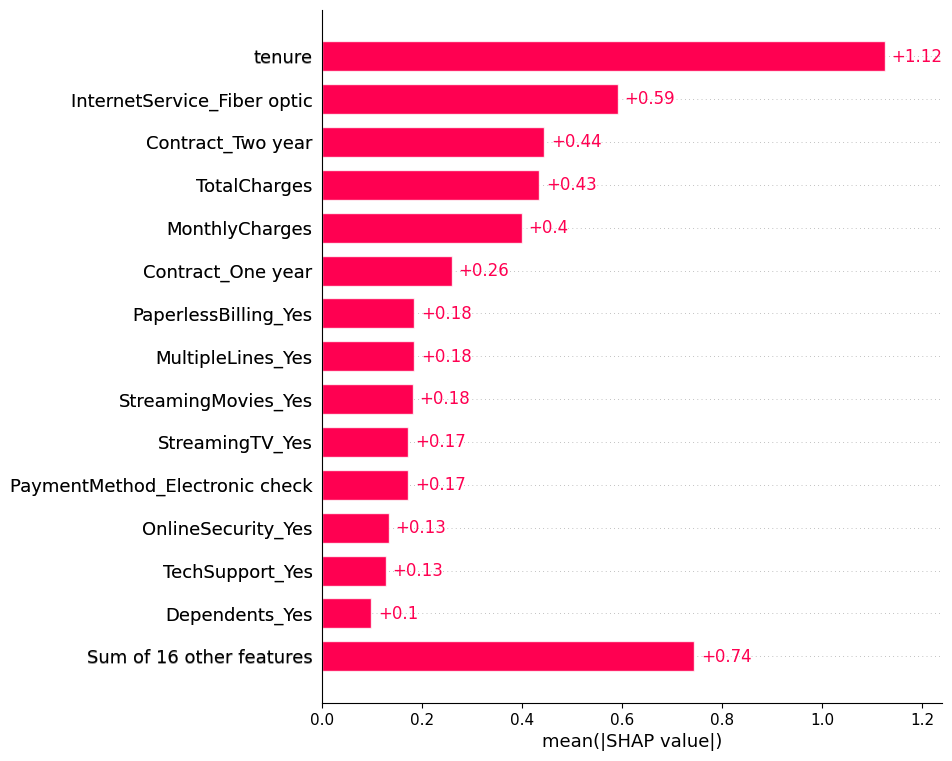

In [11]:
# Global feature importance

shap.plots.bar(
    shap_values,
    max_display=15
)

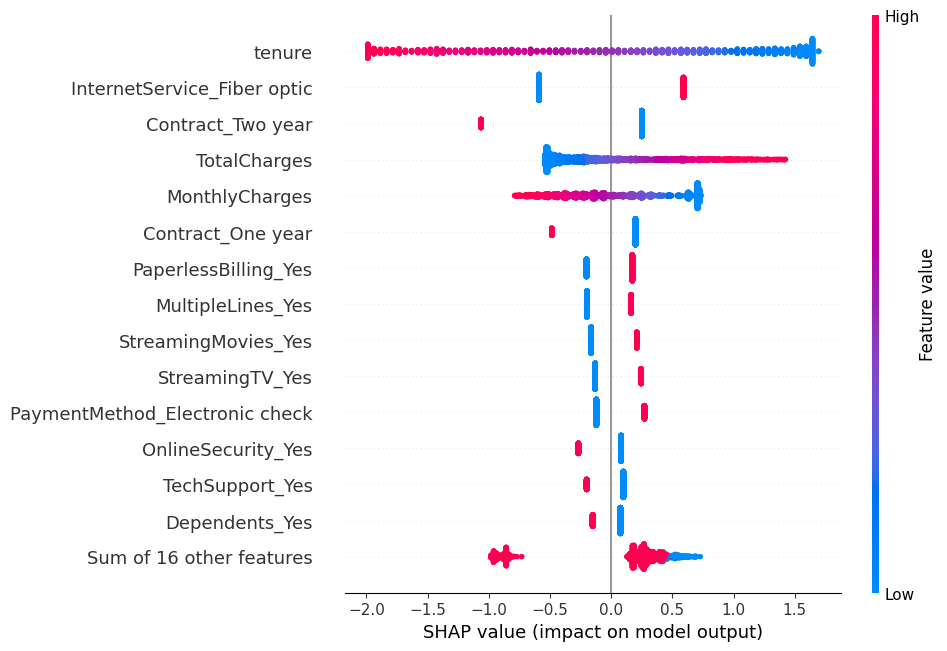

In [12]:
shap.plots.beeswarm(
    shap_values,
    max_display=15
)

In [16]:
# ==========================================
# SELECT HIGHEST RISK CUSTOMER
# ==========================================

customer_index = y_proba.argmax()

print("Customer Index:", customer_index)
print("Risk Score:", round(y_proba[customer_index], 4))

Customer Index: 1090
Risk Score: 0.8553


In [17]:
# Extract shap values for one customer

# Obtenemos la explicación SHAP
# para un único cliente.

customer_shap = shap_values[customer_index]

customer_shap


.values =
array([ 0.10649626,  1.64417087, -0.45388103, -0.5218227 ,  0.01064776,
        0.01111625,  0.07471069, -0.0468675 ,  0.02423972,  0.16274067,
        0.59033285,  0.04658073,  0.04658073,  0.08030303,  0.04658073,
        0.03127349,  0.04658073, -0.01158713,  0.04658073,  0.09875438,
        0.04658073,  0.24363992,  0.04658073,  0.20898828,  0.19831845,
        0.24962264,  0.17214006,  0.0054518 ,  0.27101478, -0.01964773])

.base_values =
np.float64(-1.6793993554997375)

.data =
array([1, -1.2816237461508113, 1.0011484313303363, -0.9671929580031219,
       True, True, False, True, False, True, True, False, False, False,
       False, False, False, False, False, False, False, True, False, True,
       False, False, True, False, True, False], dtype=object)

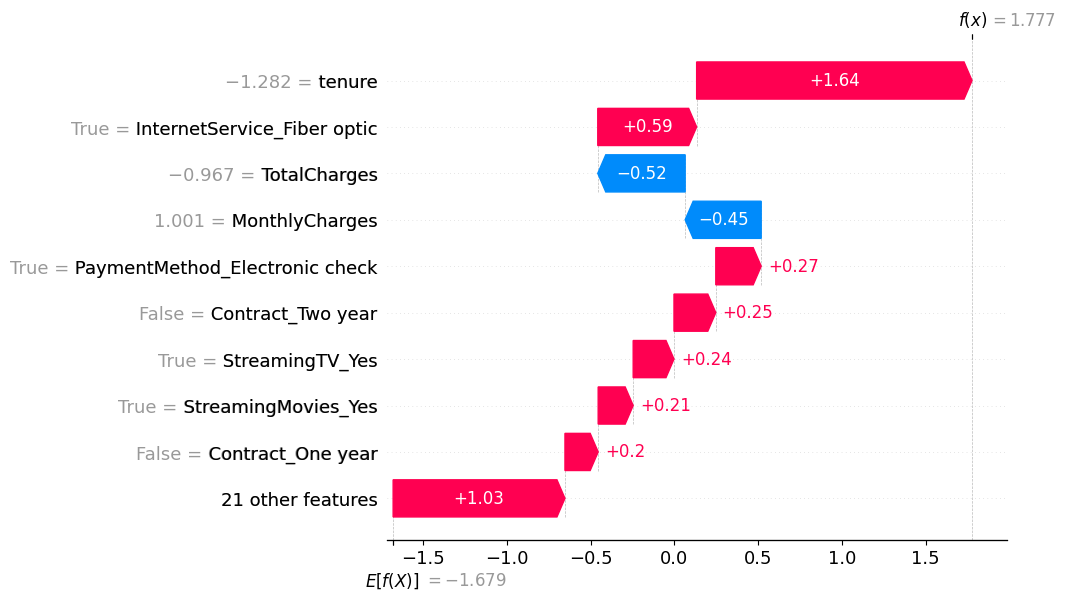

In [18]:
# Customer waterfall explanation

# Visualizamos qué variables
# aumentan o reducen el riesgo
# para este cliente específico.

shap.plots.waterfall(
    customer_shap,
    max_display=10
)

In [19]:
# Top shap drivers


In [20]:
# Create shap driver table

driver_df = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP_Value": customer_shap.values
})

driver_df.head()

,Feature,SHAP_Value
0,SeniorCitizen,0.106496
1,tenure,1.644171
2,MonthlyCharges,-0.453881
3,TotalCharges,-0.521823
4,gender_Male,0.010648


In [21]:
# Sort by absolute impact

driver_df["Abs_SHAP"] = driver_df["SHAP_Value"].abs()

driver_df = driver_df.sort_values(
    "Abs_SHAP",
    ascending=False
)

driver_df.head(10)

,Feature,SHAP_Value,Abs_SHAP
1,tenure,1.644171,1.644171
10,InternetService_Fiber optic,0.590333,0.590333
3,TotalCharges,-0.521823,0.521823
2,MonthlyCharges,-0.453881,0.453881
28,PaymentMethod_Electronic check,0.271015,0.271015
25,Contract_Two year,0.249623,0.249623
21,StreamingTV_Yes,0.243640,0.243640
23,StreamingMovies_Yes,0.208988,0.208988
24,Contract_One year,0.198318,0.198318
26,PaperlessBilling_Yes,0.172140,0.172140


In [22]:
# Positive churn drivers

positive_drivers = driver_df[
    driver_df["SHAP_Value"] > 0
]

positive_drivers.head(5)

,Feature,SHAP_Value,Abs_SHAP
1,tenure,1.644171,1.644171
10,InternetService_Fiber optic,0.590333,0.590333
28,PaymentMethod_Electronic check,0.271015,0.271015
25,Contract_Two year,0.249623,0.249623
21,StreamingTV_Yes,0.243640,0.243640


In [23]:
# Negative churn drivers

positive_drivers = driver_df[
    driver_df["SHAP_Value"] < 0
]

positive_drivers.head(5)

,Feature,SHAP_Value,Abs_SHAP
3,TotalCharges,-0.521823,0.521823
2,MonthlyCharges,-0.453881,0.453881
7,PhoneService_Yes,-0.046867,0.046867
29,PaymentMethod_Mailed check,-0.019648,0.019648
17,DeviceProtection_Yes,-0.011587,0.011587
